In [3]:
#Import necessary libraries
from scipy.stats import qmc
import numpy as np
import pandas as pd

from scipy.stats import norm
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

In [4]:
#Function 2
#Extracting updated data and turning it into a pandas dataframe
data = pd.read_csv('Data/Week 6 - Function 2.csv') 
columns = ['Input 1', 'Input 2', 'Outputs']
#Remove columns with NaN values
data = data.dropna(axis = 1)
data.columns = columns
data

,Input 1,Input 2,Outputs
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205


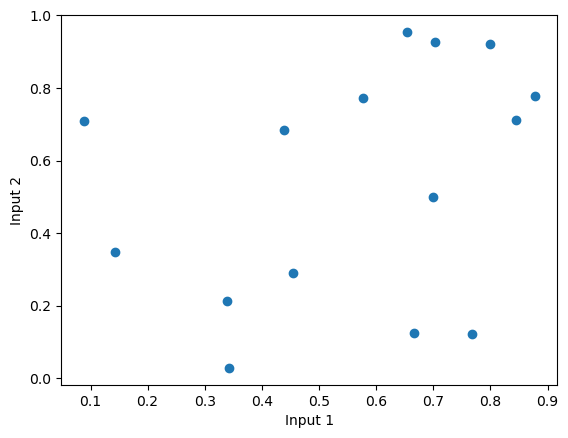

In [5]:
#Extract the Data Into Numpy Arrays
X = np.array(data[['Input 1', 'Input 2']])
Y = np.array(data[['Outputs']])

#Visualise already explored points
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:,1])
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.show()

In [6]:
# Find the pearson correlations matrix
data.corr(method = 'pearson')

,Input 1,Input 2,Outputs
Input 1,1.000000,0.328978,0.676950
Input 2,0.328978,1.000000,0.280353
Outputs,0.676950,0.280353,1.000000


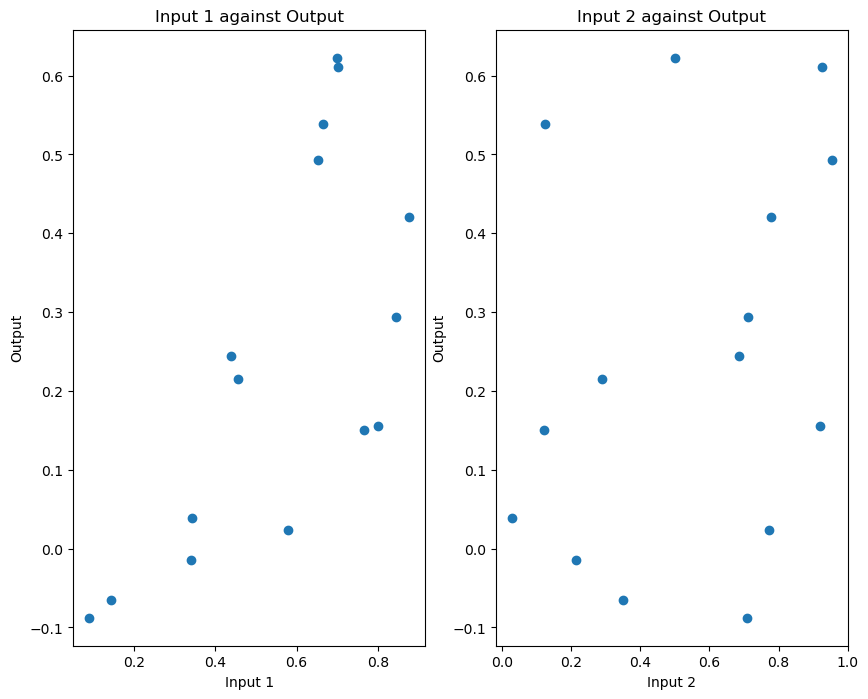

In [7]:
#Plotting each Input against the output
fig, ax = plt.subplots(1,2, figsize = (10,8))
ax[0].scatter(X[:,0], Y)
ax[1].scatter(X[:,1], Y)

#Creating titles and axis labels
ax[0].set_title('Input 1 against Output')
ax[1].set_title('Input 2 against Output')

ax[0].set_xlabel('Input 1')
ax[0].set_ylabel('Output')

ax[1].set_xlabel('Input 2')
ax[1].set_ylabel('Output')
plt.show()

In [8]:
#We now set the Kernel to be the Matern Kernel
nu = 2.5
kernel = Matern(length_scale=1.0, length_scale_bounds= (1e-2,1e1), nu = nu)
gp_best = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y = True)
gp_best.fit(X,Y)
#Use Latin hypercube sampling to create a set of candidate points 
d = 2
n = 100000
sampler = qmc.LatinHypercube(d, seed = 42)
grid = sampler.random(n)   # samples in [0,1]^d

#Fit the GP Regressor to the candidate points
mu, std = gp_best.predict(grid, return_std = True)

In [9]:
#Calculating expected improvement
best_y = np.max(Y)
eta = 0.01
z = (mu - best_y - eta) / (std + 1e-12)
ei = (mu - best_y - eta ) * norm.cdf(z) + std * norm.pdf(z)
#Find Candidate value that maximises expected improvement 
best_idx = np.argmax(ei)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.695638, 0.468807])

In [11]:
#Calculate UCB as comparison
beta = 2.5 #set exploration parameter
UCB = mu + beta * std
#Find candidate point which maximises UCB
best_idx = np.argmax(UCB)
x_next = grid[best_idx]
np.round(x_next,6)

array([0.713573, 0.445985])